In [2]:
# import the basic packages
import numpy as np

import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

import warnings 
warnings.filterwarnings(action = "ignore")

In [3]:
# import the dataset
df = pd.read_csv("titanic.csv")

In [4]:
# dataset
df[:2]

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1


---

In [5]:
# null values
df.isnull().sum()

PassengerId      0
Name             0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Survived         0
dtype: int64

In [6]:
# information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Name         891 non-null    object 
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
 11  Survived     891 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
# shape
df.shape

(891, 12)

---

In [8]:
# dataset
df[:5]

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,113803,53.1000,C123,S,1
4,5,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S,0


In [9]:
# reducing the dimensions
df.drop(columns = ["PassengerId", "Name", "Ticket", "Cabin"], inplace = True)

In [10]:
# verify
df.shape

(891, 8)

In [11]:
# dataset
df[:2]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1


---

In [12]:
# imputation
df.isnull().sum()

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
Survived      0
dtype: int64

In [13]:
# imputing the Age column
df.Age.mean() , df.Age.median(), df.Age.min(), df.Age.max()

(np.float64(29.69911764705882), 28.0, 0.42, 80.0)

In [14]:
df.Age = df.Age.fillna(30)

In [15]:
# verify
df.Age.isnull().sum()

np.int64(0)

In [16]:
# that is
df.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
Survived    0
dtype: int64

In [17]:
# shape
df.shape

(891, 8)

In [18]:
# dropping the null count from the embarked
df = df.dropna()

In [19]:
# shape
df.shape

(889, 8)

In [20]:
# verify
df.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Survived    0
dtype: int64

---

In [21]:
# dataset
df[:3]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1


In [22]:
# distribution of passenger class
df.Pclass.value_counts()

Pclass
3    491
1    214
2    184
Name: count, dtype: int64

In [23]:
# working on the Age column
df.Age.min(), df.Age.mean(), df.Age.max()

(0.42, np.float64(29.713352080989875), 80.0)

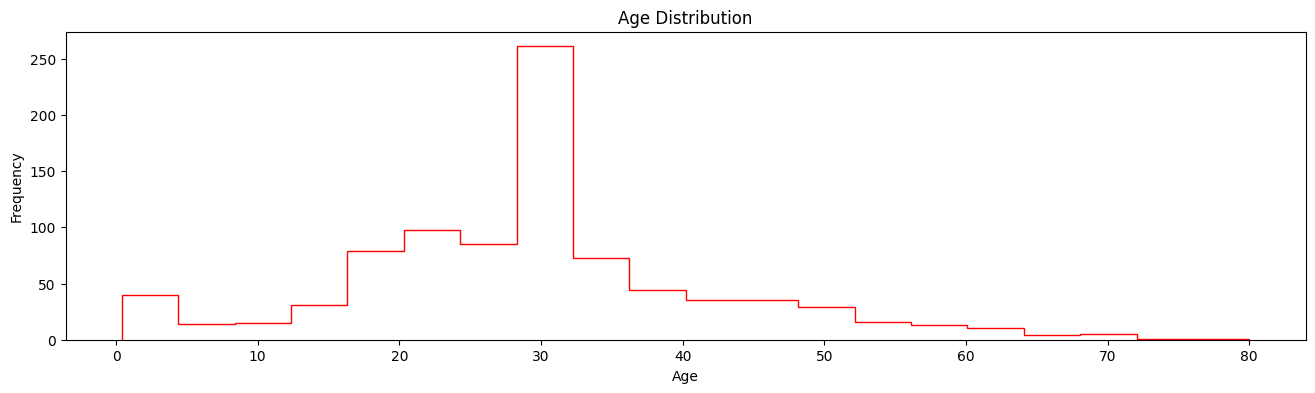

In [24]:
plt.figure(figsize = (16, 4))

plt.hist(df.Age, bins = 20, color = "red", histtype = "step")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.title("Age Distribution")

plt.show()

In [25]:
df["Age Category"] = pd.cut(df.Age, bins = [0, 15, 30, 60, 81], labels = ["Teens", "Youths", "Adults", "Senior Citizen"], 
                           
                           include_lowest = True)

In [26]:
# data
df[:2]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived,Age Category
0,3,male,22.0,1,0,7.2500,S,0,Youths
1,1,female,38.0,1,0,71.2833,C,1,Adults


In [27]:
# now, we can delete the Age column
df = df.drop("Age", axis = 1)

In [28]:
# verify
df[:1]

,Pclass,Sex,SibSp,Parch,Fare,Embarked,Survived,Age Category
0,3,male,1,0,7.25,S,0,Youths


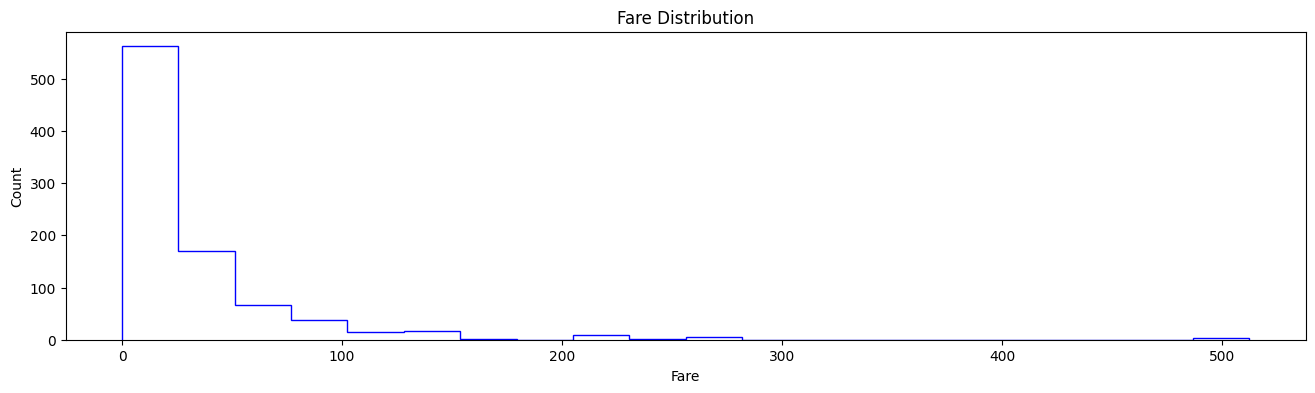

In [29]:
plt.figure(figsize = (16, 4))

plt.hist(df.Fare, bins = 20, color = "blue", histtype = "step")

plt.xlabel("Fare")

plt.ylabel("Count")

plt.title("Fare Distribution")

plt.show()

In [30]:
df["Fare Category"] = pd.cut(df.Fare, bins = [0, 100, 200, 400, 520], labels = ["low", "medium", "high", "expensive"], 
                             include_lowest = True)                            

In [31]:
# dataset
df[:2]

,Pclass,Sex,SibSp,Parch,Fare,Embarked,Survived,Age Category,Fare Category
0,3,male,1,0,7.2500,S,0,Youths,low
1,1,female,1,0,71.2833,C,1,Adults,low


In [32]:
# drop the Fare column
df.drop("Fare", axis = 1, inplace = True)

In [33]:
# verify
df[:1]

,Pclass,Sex,SibSp,Parch,Embarked,Survived,Age Category,Fare Category
0,3,male,1,0,S,0,Youths,low


In [34]:
# analysing SiblingSpouse
df.SibSp.min(), df.SibSp.max()

(0, 8)

In [35]:
# analysing ParentsChildrens
df.Parch.min(), df.Parch.max(), 

(0, 6)

In [36]:
# creating another dimension as Family
df["Family"] = df.SibSp + df.Parch

In [37]:
# verify
df[:2]

,Pclass,Sex,SibSp,Parch,Embarked,Survived,Age Category,Fare Category,Family
0,3,male,1,0,S,0,Youths,low,1
1,1,female,1,0,C,1,Adults,low,1


In [38]:
# drop the columns called SibSp, Parch

df = df.drop(columns = ["SibSp", "Parch"])

In [39]:
# view
df[:1]

,Pclass,Sex,Embarked,Survived,Age Category,Fare Category,Family
0,3,male,S,0,Youths,low,1


---

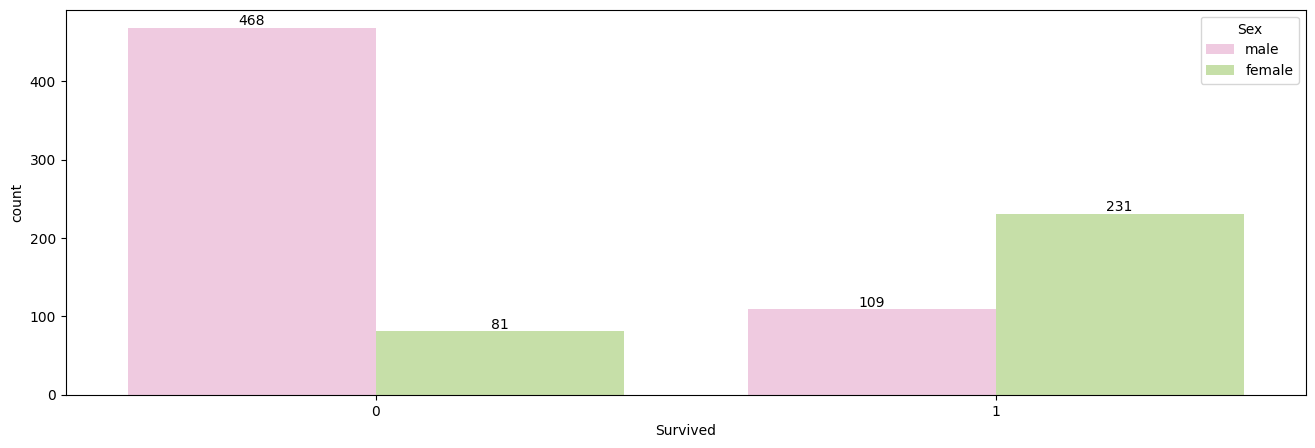

In [40]:
# analyze the distribution
plt.figure(figsize = (16, 5))

a = sns.countplot(data = df, x = "Survived", hue = "Sex", palette = "PiYG")

for container in a.containers:
    a.bar_label(container)

plt.show()

In [41]:
# dataset
df[:1]

,Pclass,Sex,Embarked,Survived,Age Category,Fare Category,Family
0,3,male,S,0,Youths,low,1


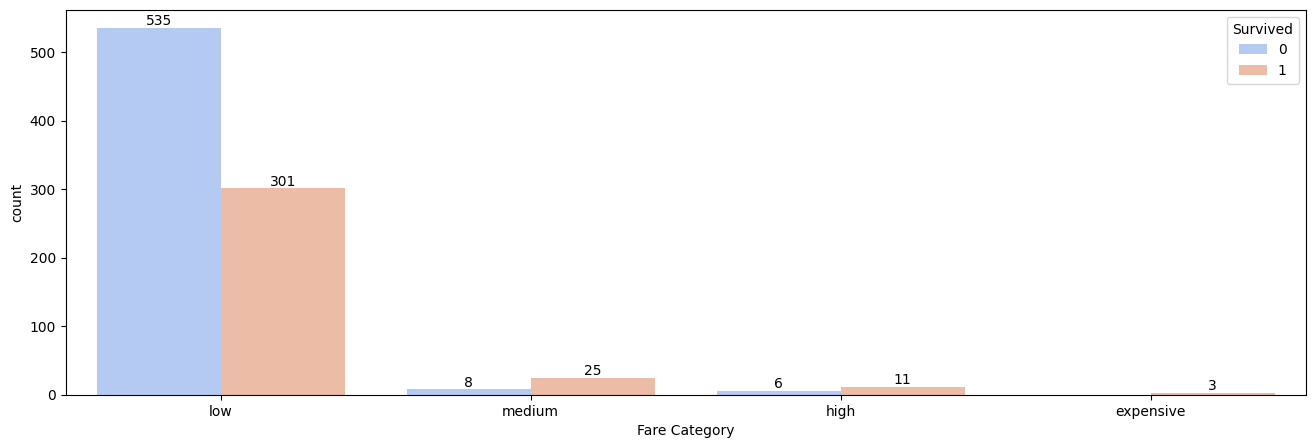

In [42]:
# analyze the distribution
plt.figure(figsize = (16, 5))

a = sns.countplot(data = df, x = "Fare Category", hue = "Survived", palette = "coolwarm")

for container in a.containers:
    a.bar_label(container)

plt.show()

---

In [43]:
# dataset
df[:2]

,Pclass,Sex,Embarked,Survived,Age Category,Fare Category,Family
0,3,male,S,0,Youths,low,1
1,1,female,C,1,Adults,low,1


In [44]:
# shape
df.shape

(889, 7)

In [45]:
# seperating X and y

x = df.drop("Survived", axis = 1)

y = df.Survived

In [46]:
# verify
x[:1]

,Pclass,Sex,Embarked,Age Category,Fare Category,Family
0,3,male,S,Youths,low,1


In [47]:
# and
y[:1]

0    0
Name: Survived, dtype: int64

In [48]:
# shape of x
x.shape

(889, 6)

In [49]:
# shape of y
y.shape

(889,)

---

In [50]:
# label encoding
from sklearn.preprocessing import LabelEncoder

In [51]:
# call and assign
le = LabelEncoder()

In [52]:
# columns
x[:2]

,Pclass,Sex,Embarked,Age Category,Fare Category,Family
0,3,male,S,Youths,low,1
1,1,female,C,Adults,low,1


In [53]:
# apply
for col in x.select_dtypes(include=['object','category']).columns:
   
    x[col] = le.fit_transform(x[col])

In [54]:
# view
x[:2]

,Pclass,Sex,Embarked,Age Category,Fare Category,Family
0,3,1,2,3,2,1
1,1,0,0,0,2,1


In [55]:
x.dtypes

Pclass           int64
Sex              int64
Embarked         int64
Age Category     int64
Fare Category    int64
Family           int64
dtype: object

In [56]:
y.dtypes

dtype('int64')

---

In [57]:
# train_test_split
from sklearn.model_selection import train_test_split

In [58]:
X_train , X_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 1)

In [59]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((711, 6), (178, 6), (711,), (178,))

In [60]:
# model building
from sklearn.tree import DecisionTreeClassifier

**“Decision Tree may overfit, so later we improve it using Random Forest”**

In [61]:
# call and assign
tree = DecisionTreeClassifier()

In [62]:
# fit the model
tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [63]:
# train accuracy
tree.score(X_train, y_train)

0.870604781997187

In [64]:
# test accuracy
tree.score(X_test, y_test)

0.7921348314606742

---

In [65]:
# confusion matrix
from sklearn.metrics import confusion_matrix

In [66]:
y_pred = tree.predict(X_test)

In [67]:
cm = confusion_matrix(y_test, y_pred)

In [68]:
cm

array([[97,  8],
       [29, 44]])

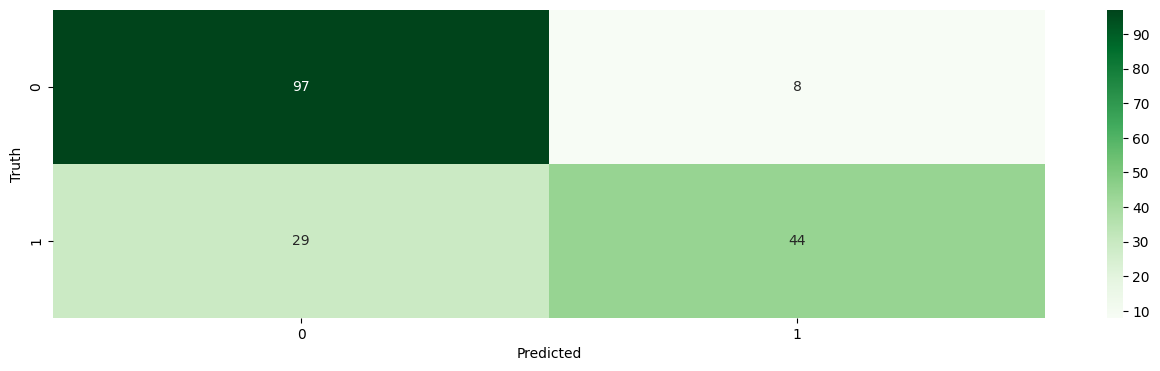

In [69]:
plt.figure(figsize = (16, 4))

sns.heatmap(cm, annot = True, cmap = "Greens")

plt.xlabel("Predicted")

plt.ylabel("Truth")

plt.show()

---

In [70]:
# classification report
from sklearn.metrics import classification_report

In [71]:
print(classification_report(y_test , y_pred)) 

              precision    recall  f1-score   support

           0       0.77      0.92      0.84       105
           1       0.85      0.60      0.70        73

    accuracy                           0.79       178
   macro avg       0.81      0.76      0.77       178
weighted avg       0.80      0.79      0.78       178



---

In [72]:
# streamlit
!pip install joblib

Defaulting to user installation because normal site-packages is not writeable


In [73]:
from joblib import dump

In [74]:
# model
dump(tree, 'tree.joblib')

['tree.joblib']

In [75]:
# columns
dump(x.columns, 'columns.joblib')

['columns.joblib']

In [76]:
# dump the saved model
dump(x, 'data.joblib')

['data.joblib']

---